In [220]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [221]:
df=pd.read_csv("loan_approval_data.csv")

In [222]:
#Handling missing data
categorical_cols=df.select_dtypes(include="object").columns
numerical_cols=df.select_dtypes(include="number").columns
num_simpleimputer=SimpleImputer(missing_values=np.nan,strategy="mean")
cat_simpleimputer=SimpleImputer(missing_values=np.nan,strategy="most_frequent")
df[numerical_cols]=num_simpleimputer.fit_transform(df[numerical_cols])
df[categorical_cols]=cat_simpleimputer.fit_transform(df[categorical_cols])

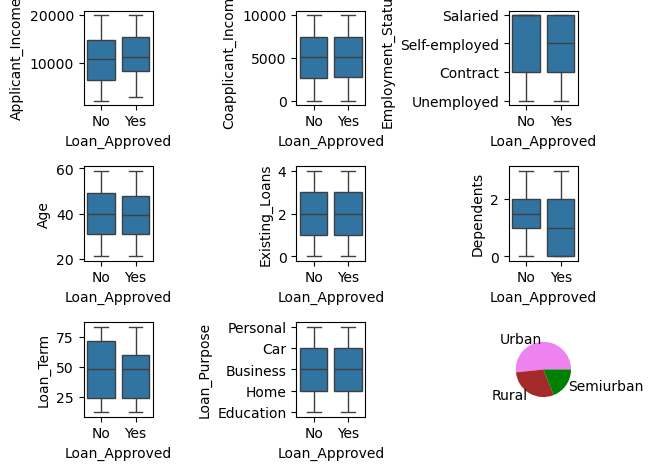

In [223]:
#Explorative Data Analysis
fig,ax=plt.subplots(3,3)
sns.boxplot(ax=ax[0][0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=ax[0][1],data=df,x="Loan_Approved",y="Coapplicant_Income")
sns.boxplot(ax=ax[0][2],data=df,x="Loan_Approved",y="Employment_Status")
sns.boxplot(ax=ax[1][0],data=df,x="Loan_Approved",y="Age")
sns.boxplot(ax=ax[1][1],data=df,x="Loan_Approved",y="Existing_Loans")
sns.boxplot(ax=ax[1][2],data=df,x="Loan_Approved",y="Dependents")
sns.boxplot(ax=ax[2][0],data=df,x="Loan_Approved",y="Loan_Term")
sns.boxplot(ax=ax[2][1],data=df,x="Loan_Approved",y="Loan_Purpose")
counts=df["Property_Area"].value_counts()
ax[2][2].pie(counts,labels=counts.index,colors=["violet","brown","green"])
fig.tight_layout()

In [224]:
df=df.drop(columns=["Applicant_ID"])#because it has no intend to train

In [225]:
#Encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
le = LabelEncoder()
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df["Education_Level"]=le.fit_transform(df["Education_Level"])
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe=OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
ohe_array=ohe.fit_transform(df[cols])
ohe_df=pd.DataFrame(ohe_array,columns=ohe.get_feature_names_out(cols),index=df.index)
df=pd.concat([df.drop(columns=cols),ohe_df],axis=1)
df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


<Axes: >

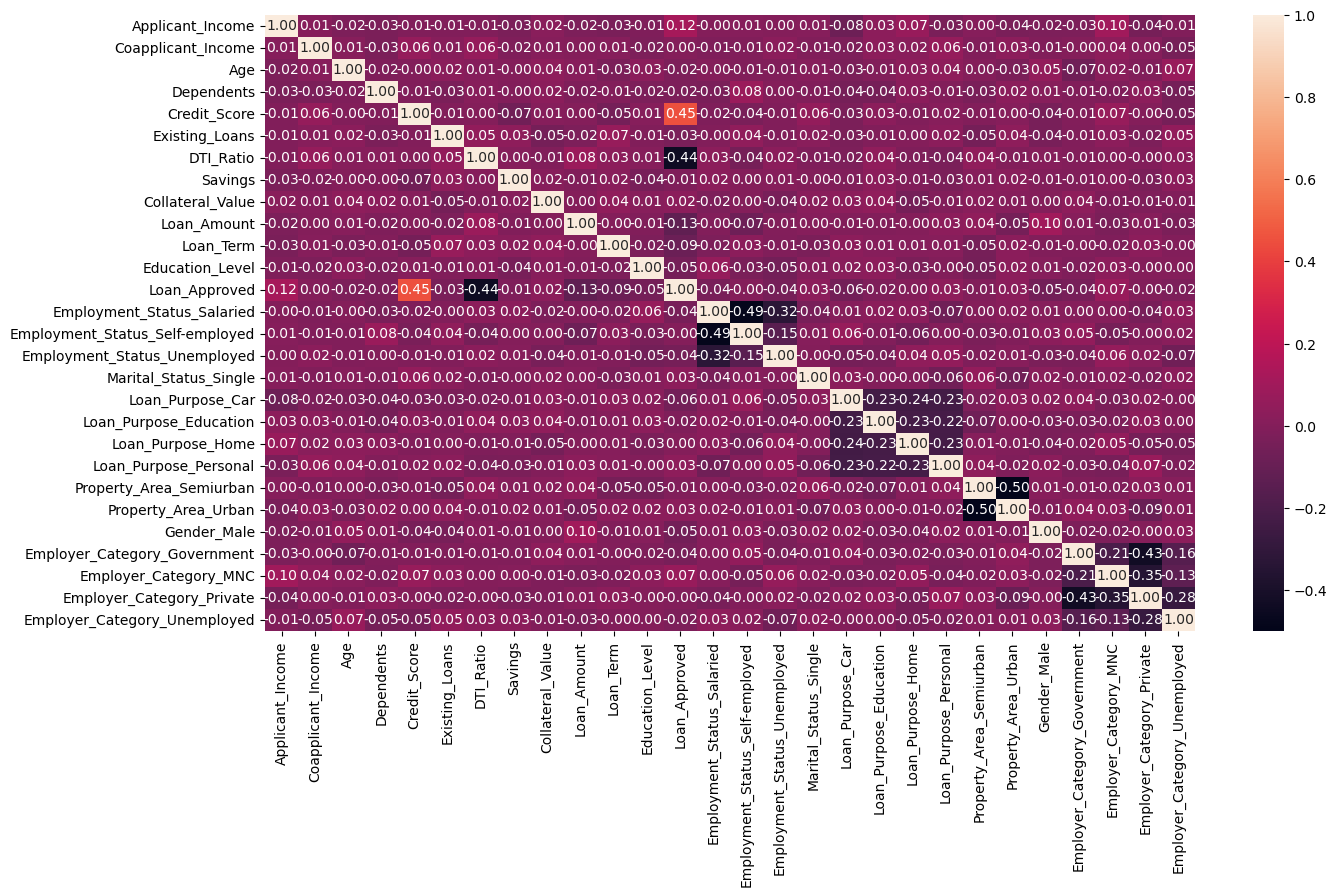

In [226]:
#correlation
num_cols=df.select_dtypes(include="number")
col_matrix=num_cols.corr()
col_matrix
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)
plt.figure(figsize=(15,8))
sns.heatmap(col_matrix,annot=True,fmt=".2f")

In [227]:
#Fearute Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df.drop(columns=["Loan_Approved"])
y=df["Loan_Approved"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [228]:
#Logistic
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
lmodel=LogisticRegression()
lmodel.fit(X_train,y_train)
y_pred=lmodel.predict(X_test)
print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("precision Score : ",precision_score(y_test,y_pred))
print("recall Score : ",recall_score(y_test,y_pred))
print("f1 Score : ",f1_score(y_test,y_pred))
print("CM : ",confusion_matrix(y_test,y_pred))

Accuracy Score :  0.865
precision Score :  0.7833333333333333
recall Score :  0.7704918032786885
f1 Score :  0.7768595041322314
CM :  [[126  13]
 [ 14  47]]


In [229]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
lmodel=KNeighborsClassifier(n_neighbors=5)
lmodel.fit(X_train,y_train)
y_pred=lmodel.predict(X_test)
print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("precision Score : ",precision_score(y_test,y_pred))
print("recall Score : ",recall_score(y_test,y_pred))
print("f1 Score : ",f1_score(y_test,y_pred))
print("CM : ",confusion_matrix(y_test,y_pred))

Accuracy Score :  0.76
precision Score :  0.6274509803921569
recall Score :  0.5245901639344263
f1 Score :  0.5714285714285714
CM :  [[120  19]
 [ 29  32]]


In [230]:
#naiveBayes#best
from sklearn.naive_bayes import GaussianNB
lmodel=GaussianNB()
lmodel.fit(X_train,y_train)
y_pred=lmodel.predict(X_test)
print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("precision Score : ",precision_score(y_test,y_pred))
print("recall Score : ",recall_score(y_test,y_pred))
print("f1 Score : ",f1_score(y_test,y_pred))
print("CM : ",confusion_matrix(y_test,y_pred))

Accuracy Score :  0.865
precision Score :  0.8035714285714286
recall Score :  0.7377049180327869
f1 Score :  0.7692307692307693
CM :  [[128  11]
 [ 16  45]]
